In [1]:
# import getdist.plots as gdplt
# from cobaya import load_samples
import matplotlib.pyplot as plt
import numpy as np
import camb
import cosmoprimo
import os
# from scipy.stats import linregress
# from scipy.optimize import curve_fit

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

plt.rc('xtick', labelsize=12) 
plt.rc('ytick', labelsize=12)
plt.rc('font', size=14)
plt.rc('axes', labelsize=16)

# looking at forecasted errors on $D_M/r_d$ and $D_H/r_d$

## fct def

In [2]:
def get_DESI_errors():
    dict_distance, z_DESI, path = get_DESI_data()

    cov_mat = np.loadtxt(path.replace('mean', 'cov'))

    errors = {}
    for i in range(len(cov_mat[0, :])):
        z = z_DESI[i//2]
        if i == 0:
            _, _, DVfid = get_DESI_fid(z)
            a_iso_err = np.sqrt(cov_mat[i][i]) / DVfid
            errors[z] = {'d_iso': a_iso_err}
        elif i%2 == 0:
            cov = [[cov_mat[i-1, i-1], cov_mat[i-1, i]], [cov_mat[i, i-1], cov_mat[i, i]]]
            sig_x = np.sqrt(cov[0][0])
            sig_y = np.sqrt(cov[1][1])

            DMfid, DHfid, DVfid = get_DESI_fid(z)
            if i == len(cov_mat[0, :])-1:
                d_a_perp = sig_y / DMfid
                d_a_par = sig_x / DHfid                
            else :
                d_a_perp = sig_x / DMfid
                d_a_par = sig_y / DHfid

            DM = dict_distance[z]['DM_over_rs']
            DH = dict_distance[z]['DH_over_rs']
            DV = (z*DM**2*DH)**(1/3)

            a_perp = DM / DMfid
            a_par = DH / DHfid
            a_iso = DV / DVfid
            a_AP = a_par / a_perp

            d_a_AP = a_AP * np.sqrt((d_a_par / a_par)**2 + (d_a_perp / a_perp)**2)
            d_a_iso = a_iso * np.sqrt((2/3)**3 * (d_a_perp / a_perp)**2 + (1/3)**2 * (d_a_par / a_par)**2)

            errors[z] = {'d_perp':  d_a_perp,
                         'd_par':   d_a_par,
                         'd_AP':    d_a_AP,
                         'd_iso':   d_a_iso
                         }
    return errors, z_DESI

def get_DESI_data():
    z_DESI = []
    path = r'C:\EPFL\MA4\code\COBAYA_packages\data\bao_data\desi_bao_dr2\desi_gaussian_bao_ALL_GCcomb_mean.txt'
    with open(path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            parts = line.split()
            z_DESI.append(float(parts[0]))

    z_DESI = set(z_DESI)
    z_DESI = list(z_DESI)
    z_DESI.sort()
    dict_distance = {}
    for z in z_DESI:
        dict_distance[z] = {}

    with open(path, 'r') as f:
        for line in f:
            if line.startswith('#'):
                continue
            parts = line.split()
            z = float(parts[0])
            for key in dict_distance.keys():
                if key == z:
                    dict_distance[key][parts[2]] = float(parts[1])
    
    return dict_distance, z_DESI, path

def get_DESI_fid(redshift):
    DESI = cosmoprimo.fiducial.DESI(engine='camb')
    DESI_bkg = DESI.get_background()
    DESI_thermo = DESI.get_thermodynamics()
    rdrag_fid = DESI_thermo.rs_drag
    DM_fid = DESI_bkg.comoving_angular_distance(redshift)
    DH_fid = 1 / DESI_bkg.efunc(redshift) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV_fid = (redshift * DM_fid**2 * DH_fid)**(1/3)
    DMover_rd_fid = DM_fid / rdrag_fid
    DHover_rd_fid = DH_fid / rdrag_fid
    DVover_rd_fid = DV_fid / rdrag_fid

    return DMover_rd_fid, DHover_rd_fid, DVover_rd_fid

In [ ]:
def extract_error_bars(cov_mat, DESI_style=False):
    n = len(cov_mat[0, :])
    err_DM = []
    err_DH = []

    if DESI_style:
        cov_mat = np.delete(cov_mat, 0, axis=0)  # Remove the first row
        cov_mat = np.delete(cov_mat, 0, axis=1)  # Remove the first column
        n = len(cov_mat[0, :])  
    
    for i in range(n):
        if i%2 == 0:
            sig_x = np.sqrt(cov_mat[i][i])
            sig_y = np.sqrt(cov_mat[i+1][i+1])
            err_DM.append(sig_x)
            err_DH.append(sig_y)
    
    return err_DM, err_DH

In [ ]:
z = np.linspace(0.01, 3, 100)

DM, DH, _ = get_DESI_fid(z)

DESI_errors, z_DESI = get_DESI_errors()
DM_fid, DH_fid, DV_fid = get_DESI_fid(z_DESI[1:])
print(DM_fid, DH_fid, DV_fid)

DM_err_DESI = [DESI_errors[z]['d_perp'] for z in z_DESI[1:]]
DH_err_DESI = [DESI_errors[z]['d_par'] for z in z_DESI[1:]]
print(DM_err_DESI, DH_err_DESI)

DM_DESI, DH_DESI, _ = get_DESI_fid(z_DESI[1:])

[13.50104902 17.7014161  21.99560786 28.08262104 30.2765591  39.18333978] [22.74072325 20.16983343 17.56927775 14.06486518 12.87994207  8.61571762] [12.83423023 16.46295072 19.94914286 24.47022091 25.9728903  31.35331213]
[np.float64(0.012470644654042889), np.float64(0.010164792451377339), np.float64(0.007355176867306331), np.float64(0.011557178886058698), np.float64(0.025219432708804546), np.float64(0.013569083972711728)] [np.float64(0.01885904507329651), np.float64(0.016552939454103098), np.float64(0.011442886353762142), np.float64(0.01596541083642338), np.float64(0.04021848595189285), np.float64(0.011730009899853384)]


## Tests

In [ ]:
# tests
cov_test1_fsky25 = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\test1_fsky25\cov_alpha.txt')
z_test1_fsky25 = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\test1_fsky25\redshifts.txt')

cov_test1_fsky25_5bins = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\test1_fsky25_5bins\cov_alpha.txt')
z_test1_fsky25_5bins = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\test1_fsky25_5bins\redshifts.txt')

cov_test1_fsky75 = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\test1_fsky75\cov_alpha.txt')
z_test1_fsky75 = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\test1_fsky75\redshifts.txt')

cov_test1_fsky75_5bins = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\test1_fsky75_5bins\cov_alpha.txt')
z_test1_fsky75_5bins = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\test1_fsky75_5bins\redshifts.txt')

In [ ]:
err_DM_test1_fsky25, err_DH_test1_fsky25 = extract_error_bars(cov_test1_fsky25)
err_DM_test1_fsky25_5bins, err_DH_test1_fsky25_4bins = extract_error_bars(cov_test1_fsky25_5bins)
err_DM_test1_fsky75, err_DH_test1_fsky75 = extract_error_bars(cov_test1_fsky75)
err_DM_test1_fsky75_5bins, err_DH_test1_fsky75_4bins = extract_error_bars(cov_test1_fsky75_5bins)

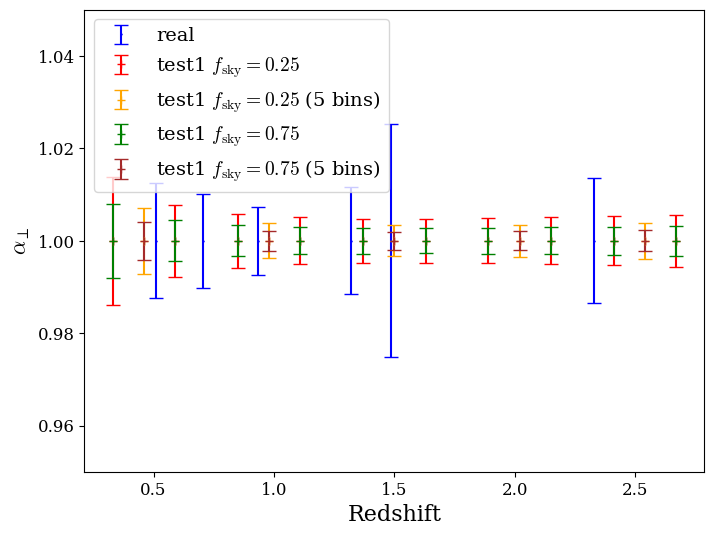

In [12]:
# test
plt.figure(figsize=(8, 6))
plt.errorbar(z_DESI[1:], [1 for _ in z_DESI[1:]], yerr=DM_err_DESI, fmt='+', capsize=5, ms=2, label='real', color='blue')
plt.errorbar(z_test1_fsky25, [1 for _ in z_test1_fsky25], yerr=err_DM_test1_fsky25, fmt='+', capsize=5, label=r'test1 $f_\mathrm{sky}=0.25$', color='red')
plt.errorbar(z_test1_fsky25_5bins, [1 for _ in z_test1_fsky25_5bins], yerr=err_DM_test1_fsky25_5bins, fmt='+', capsize=5, label=r'test1 $f_\mathrm{sky}=0.25$ (5 bins)', color='orange')
plt.errorbar(z_test1_fsky75, [1 for _ in z_test1_fsky75], yerr=err_DM_test1_fsky75, fmt='+', capsize=5, label=r'test1 $f_\mathrm{sky}=0.75$', color='green')
plt.errorbar(z_test1_fsky75_5bins, [1 for _ in z_test1_fsky75_5bins], yerr=err_DM_test1_fsky75_5bins, fmt='+', capsize=5, label=r'test1 $f_\mathrm{sky}=0.75$ (5 bins)', color='brown')

plt.ylim(0.95, 1.05)
# plt.ylim(0.992, 1.008)

plt.xlabel('Redshift')
plt.ylabel(r'$\alpha_\perp$')
plt.legend(loc='upper left')

In [13]:
# get ratios of errors
def get_error_ratios(err1, err2):
    ratios = []
    for i in range(len(err1)):
        ratio = err1[i] / err2[i]
        ratios.append(ratio)
    return ratios

In [14]:
get_error_ratios(err_DM_test1_fsky25, err_DM_test1_fsky75)

[np.float64(1.7320508080225208),
 np.float64(1.7320508090034636),
 np.float64(1.7320508075688774),
 np.float64(1.7320508082412882),
 np.float64(1.7320508068176719),
 np.float64(1.7320508071867249),
 np.float64(1.7320508093948606),
 np.float64(1.7320508095936304),
 np.float64(1.7320508060435498),
 np.float64(1.7320508075688774)]

In [17]:
get_error_ratios(err_DM_test1_fsky25_5bins, err_DM_test1_fsky75_5bins)

[np.float64(1.7320508058748345),
 np.float64(1.7320508099714296),
 np.float64(1.7320508045020928),
 np.float64(1.7320508068650524),
 np.float64(1.7320508064162987)]

In [16]:
np.sqrt(3)

np.float64(1.7320508075688772)

## Figures

In [ ]:
cov_DESI2nP1 = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\DESI2nP=1\cov_alpha.txt')
z_DESInP1 = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\DESI2nP=1\redshifts.txt')

cov_DESI2fullsky = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\DESI2_fullsky\cov_alpha.txt')
z_DESIfullsky = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\DESI2_fullsky\redshifts.txt')

cov_DESI = np.loadtxt(r'C:\EPFL\MA4\code\COBAYA_packages\data\bao_data\desi_bao_dr2\desi_gaussian_bao_ALL_GCcomb_cov.txt')

cov_DESI3 = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\DESI3\cov_alpha.txt')
z_DESI3 = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\DESI3\redshifts.txt')

cov_DESI3_14bins = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\DESI3_14bins\cov_alpha.txt')
z_DESI3_14bins = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\DESI3_14bins\redshifts.txt')

cov_DESI3_7bins = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\DESI3_7bins\cov_alpha.txt')
z_DESI3_7bins = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\DESI3_7bins\redshifts.txt')

cov_DESI3_14bins_fullsky = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\DESI3nP=1_fullsky\cov_alpha.txt')
z_DESI3_14bins_fullsky = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\DESI3nP=1_fullsky\redshifts.txt')

cov_Euclid = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\Euclid\cov_alpha.txt')
z_Euclid = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\Euclid\redshifts.txt')

cov_DESI3_nP1_fullsky = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\DESI3nP=1_fullsky\cov_alpha.txt')
z_DESI3_nP1_fullsky = np.loadtxt(r'C:\EPFL\MA4\code\PDM2026\forecast_cov_mat\DESI3nP=1_fullsky\redshifts.txt')

get errors

In [ ]:
err_DM_nP1, err_DH_nP1 = extract_error_bars(cov_DESI2nP1)
err_DM_fullsky, err_DH_fullsky = extract_error_bars(cov_DESI2fullsky)

err_DM_3, err_DH_3 = extract_error_bars(cov_DESI3)

err_DM_real, err_DH_real = extract_error_bars(cov_DESI, DESI_style=True)

err_DM_3_14bins, err_DH_3_14bins = extract_error_bars(cov_DESI3_14bins)

err_DM_3_7bins, err_DH_3_7bins = extract_error_bars(cov_DESI3_7bins)

err_DM_3_14bins_fullsky, err_DH_3_14bins_fullsky = extract_error_bars(cov_DESI3_14bins_fullsky)

err_DM_Euclid, err_DH_Euclid = extract_error_bars(cov_Euclid)

err_DM_3_nP1_fullsky, err_DH_3_nP1_fullsky = extract_error_bars(cov_DESI3_nP1_fullsky)


get values of DM/rd and DH/rd

In [ ]:
DM_nP1, DH_nP1, _ = get_DESI_fid(z_DESInP1)

DM_fullsky, DH_fullsky, _ = get_DESI_fid(z_DESIfullsky)

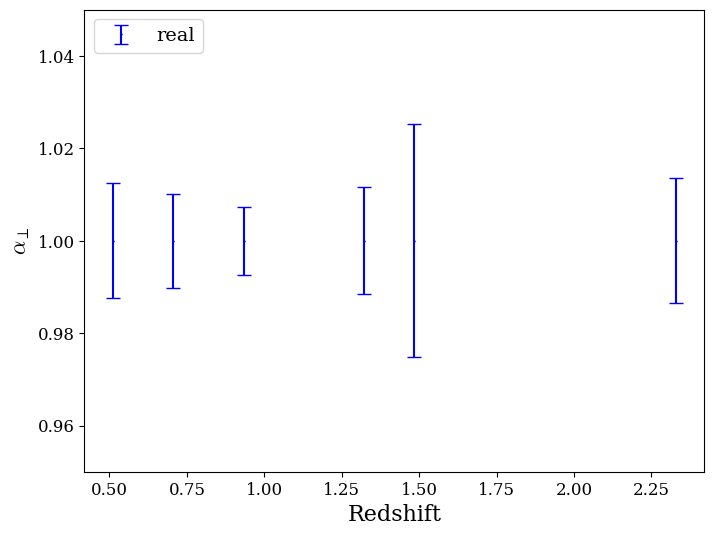

In [11]:
plt.figure(figsize=(8, 6))
plt.errorbar(z_DESI[1:], [1 for _ in z_DESI[1:]], yerr=DM_err_DESI, fmt='+', capsize=5, ms=2, label='real', color='blue')
# plt.errorbar(z_DESInP1, [1 for _ in z_DESInP1], yerr=err_DM_nP1, fmt='+', capsize=5, label='nP=1', color='magenta')
# plt.errorbar(z_DESIfullsky + 0.015, [1 for _ in z_DESIfullsky], yerr=err_DM_fullsky, fmt='x', ms=1, label='full sky', color='green')
# plt.errorbar(z_DESI3, [1 for _ in z_DESI3], yerr=err_DM_3, fmt='x', ms=1, label='28 bins', color='red', alpha=0.4)
# plt.errorbar(z_DESI3_14bins, [1 for _ in z_DESI3_14bins], yerr=err_DM_3_14bins, fmt='x', ms=1, label='14 bins', color='green', alpha=0.4)
# plt.errorbar(z_DESI3_7bins, [1 for _ in z_DESI3_7bins], yerr=err_DM_3_7bins, fmt='x', ms=1, label='7 bins', color="#00418B", alpha=0.8)
# plt.errorbar(z_DESI3_14bins_fullsky, [1 for _ in z_DESI3_14bins_fullsky], yerr=err_DM_3_14bins_fullsky, fmt='x', ms=1, 
            #  capsize=5, label='14 bins fullsky $nP=1$', color='orange', alpha=0.8)
# plt.errorbar(z_Euclid, [1 for _ in z_Euclid], yerr=err_DM_Euclid, fmt='x', ms=1, capsize=5, label='Euclid', color='orange', alpha=1)
# plt.errorbar(z_DESI3_nP1_fullsky, [1 for _ in z_DESI3_nP1_fullsky], yerr=err_DM_3_nP1_fullsky, fmt='x', ms=1, capsize=5)

plt.ylim(0.95, 1.05)
# plt.ylim(0.992, 1.008)

plt.xlabel('Redshift')
plt.ylabel(r'$\alpha_\perp$')
plt.legend(loc='upper left')

In [37]:
print(z_DESI3)

[0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9
 2.  2.1 2.2 2.3 2.4 2.5 2.6 2.7 2.8 2.9]


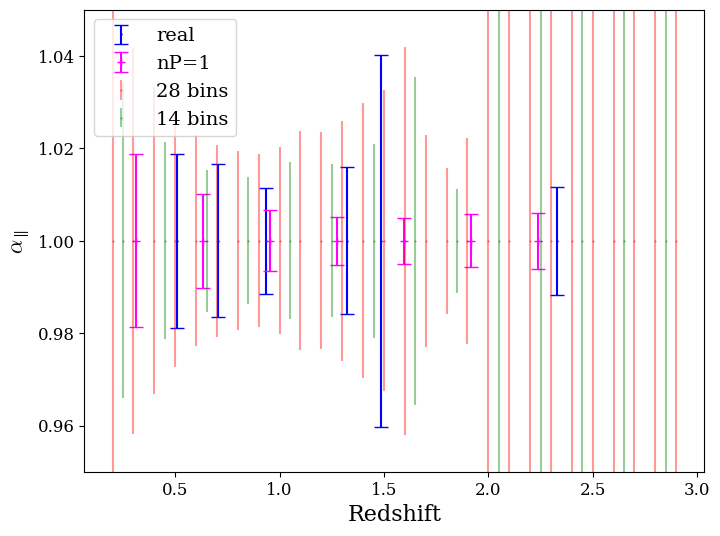

In [41]:
plt.figure(figsize=(8, 6))
plt.errorbar(z_DESI[1:], [1 for _ in z_DESI[1:]], yerr=DH_err_DESI, fmt='+', capsize=5, ms=2, label='real', color='blue')
plt.errorbar(z_DESInP1, [1 for _ in z_DESInP1], yerr=err_DH_nP1, fmt='+', capsize=5, label='nP=1', color='magenta')
# plt.errorbar(z_DESIfullsky + 0.015, [1 for _ in z_DESIfullsky], yerr=err_DH_fullsky, fmt='x', ms=1, label='full sky', color='green')
plt.errorbar(z_DESI3, [1 for _ in z_DESI3], yerr=err_DH_3, fmt='x', ms=1, label='28 bins', color='red', alpha=0.4)
plt.errorbar(z_DESI3_14bins, [1 for _ in z_DESI3_14bins], yerr=err_DH_3_14bins, fmt='x', ms=1, label='14 bins', color='green', alpha=0.4)
# plt.errorbar(z_DESI3_7bins, [1 for _ in z_DESI3_7bins], yerr=err_DH_3_7bins, fmt='x', ms=1, label='7 bins', color="#00418B", alpha=0.8)
# plt.errorbar(z_DESI3_14bins_fullsky, [1 for _ in z_DESI3_14bins_fullsky], yerr=err_DH_3_14bins_fullsky, fmt='x', ms=1, 
#              capsize=5, label='14 bins fullsky $nP=1$', color='orange', alpha=0.8)
# plt.errorbar(z_Euclid, [1 for _ in z_Euclid], yerr=err_DH_Euclid, fmt='x', ms=1, capsize=5, label='Euclid', color='orange', alpha=1)

plt.ylim(0.95, 1.05)

plt.xlabel('Redshift')
plt.ylabel(r'$\alpha_\parallel$')
plt.legend(loc='upper left')

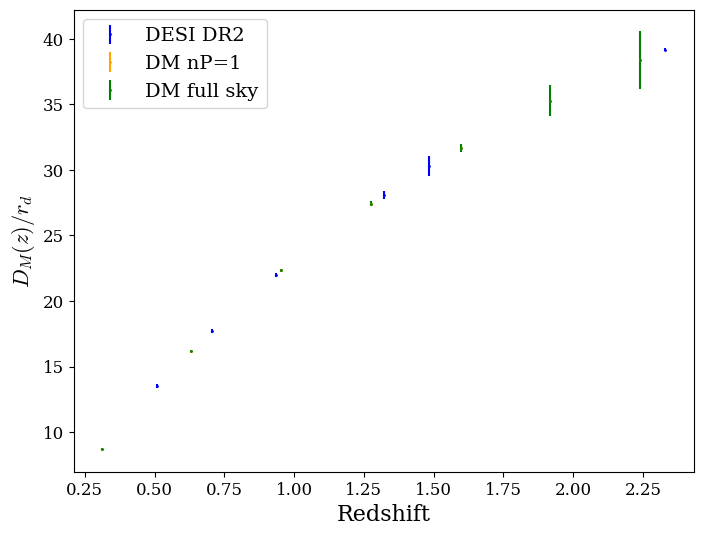

In [ ]:
# plt.figure(figsize=(8, 6))
# plt.errorbar(z_DESI[1:], DM_DESI, yerr=err_DM_real, fmt='o', ms=1, label='DESI DR2', color='blue')
# plt.errorbar(z_DESInP1, DM_nP1, yerr=err_DM_nP1, fmt='o', ms=1, label='DM nP=1', color='orange')
# plt.errorbar(z_DESIfullsky, DM_fullsky, yerr=err_DM_fullsky, fmt='o', ms=1, label='DM full sky', color='green')

# plt.xlabel('Redshift')
# plt.ylabel('$D_M(z)/r_d$')
# plt.legend()

In [17]:
print(DESI_errors)

{0.295: {'d_iso': np.float64(0.009443805186345236)}, 0.51: {'d_perp': np.float64(0.012470644654042889), 'd_par': np.float64(0.01885904507329651), 'd_AP': np.float64(0.022164470794711507), 'd_iso': np.float64(0.009311219850889802)}, 0.706: {'d_perp': np.float64(0.010164792451377339), 'd_par': np.float64(0.016552939454103098), 'd_AP': np.float64(0.019731529337334193), 'd_iso': np.float64(0.007835268456705378)}, 0.934: {'d_perp': np.float64(0.007355176867306331), 'd_par': np.float64(0.011442886353762142), 'd_AP': np.float64(0.013964362169841288), 'd_iso': np.float64(0.005512107843048921)}, 1.321: {'d_perp': np.float64(0.011557178886058698), 'd_par': np.float64(0.01596541083642338), 'd_AP': np.float64(0.02023073569667844), 'd_iso': np.float64(0.008223888113314702)}, 1.484: {'d_perp': np.float64(0.025219432708804546), 'd_par': np.float64(0.04021848595189285), 'd_AP': np.float64(0.0469391250482571), 'd_iso': np.float64(0.019226258247815334)}, 2.33: {'d_perp': np.float64(0.013569083972711728)

In [ ]:
def plot_DM_DH_2panels(redshift, slope, offset, param_cosmo, ylim=None, yticks=None, text_loc='lower right', 
                                name='', path_save=None, xlabel=True, show_plots=True, DESI_errors=None,
                                envelope_settings=None, symmetric=False, AP_ISO = True):
    
    if AP_ISO:
        alph_AP   = []
        alph_ISO  = []
    else:
        alph_perp = []
        alph_par  = []

    w0 = [cosmo[0] for cosmo in param_cosmo]

    for i in range(len(w0)):
        a, b, c = alpha_perp_parallel(redshift, param_cosmo[i])
        if AP_ISO:
            alph_AP.append(b / a)
            alph_ISO.append(c)
        else:
            alph_perp.append(a)
            alph_par.append(b)

    cmap = cm.viridis
    w0min, w0max = min(w0), max(w0)

    if symmetric:
        if w0max < -0.8: w0max = -0.8
        if w0min > -1.2: w0min = -1.2
    else:
        if w0max < -0.5: w0max = -0.5
        if w0min > -1.1: w0min = -1.1

    norm = mcolors.Normalize(vmin=w0min, vmax=w0max)

    fig = plt.figure(figsize=(10, 3.5))
    gs = fig.add_gridspec(
            1, 2,
        wspace=0.32, hspace=0.3
    )

    ax00 = fig.add_subplot(gs[0, 0])
    ax01 = fig.add_subplot(gs[0, 1])

    axes = {'00': ax00, '01': ax01}
    if AP_ISO:
        data = {'00': alph_ISO, '01': alph_AP}
        ylabels = {
            '00': r'$\alpha_\mathrm{ISO}(z)$',
            '01': r'$\alpha_\mathrm{AP}(z)$'
            }        
    else:
        data = {'00': alph_perp, '01': alph_par}
        ylabels = {
            '00': r'$\alpha_\perp(z)$',
            '01': r'$\alpha_\parallel(z)$'
            }


        # if envelope_settings is not None:
        #     envelope_type = envelope_settings['type']
        #     if envelope_type == 'spline':
        #         a = envelope_settings['alpha']
        #         k = envelope_settings['k']
        #         smooth = envelope_settings['smooth']
        #         from scipy.interpolate import UnivariateSpline
        #         z_fine = np.linspace(0, 3, 200)
        #         spline = UnivariateSpline(z_DESI_uncert, a_perp_err, s=smooth, k=k)  # s contrôle le lissage
        #         ax10.fill_between(z_fine, 1 - spline(z_fine), 1 + spline(z_fine), color='k', alpha=a)
        
        # from scipy.interpolate import interp1d

        # z_fine = np.linspace(min(z_DESI_uncert), max(z_DESI_uncert), 200)
        # z_fine = np.linspace(0, 3, 200)
        # err_interp = interp1d(z_DESI_uncert, a_perp_err, kind='cubic', fill_value='extrapolate')
        # ax10.fill_between(z_fine, 1 - err_interp(z_fine), 1 + err_interp(z_fine), color='k', alpha=0.2)
    
    if DESI_errors is not None:
        uncert, z_uncert = get_DESI_errors()
        a_perp_err = []
        a_par_err = []
        a_iso_err = []
        a_AP_err = []
        for idx, (_, value) in enumerate(uncert.items()):
            if idx == 0:
                a_iso_err.append(value['d_iso'])
            else:
                a_perp_err.append(value['d_perp'])
                a_par_err.append(value['d_par'])
                a_AP_err.append(value['d_AP'])
                a_iso_err.append(value['d_iso'])
        a_err = [a_iso_err, a_AP_err, a_perp_err, a_par_err]
    
    if AP_ISO:
        a_err = a_err[:2]
    else:
        a_err = a_err[2:]

    for idx, (key, ax) in enumerate(axes.items()):
        for i in range(len(w0)):
            ax.plot(redshift, data[key][i], color=cmap(norm(w0[i])))
    
        if DESI_errors is not None:
            if idx == 0 and AP_ISO:
                ax.errorbar(z_uncert, [1 for _ in z_uncert], yerr=a_err[idx], fmt='o', color='k', markersize=3)
            else:
                ax.errorbar(z_uncert[1:], [1 for _ in z_uncert[1:]], yerr=a_err[idx], fmt='o', color='k', markersize=3)

        ax.axhline(1, color='k', ls='--', lw=1)

        ax.tick_params(which='major', direction='in', length=4, width=1,   top=True, right=True)
        ax.tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())

        ax.set_ylabel(ylabels[key], fontsize=18)
        ax.set_xlim(0, 3)

        if ylim is not None:
            if 'all' in ylim:
                ax.set_ylim(ylim['all'])
            elif key in ylim:
                ax.set_ylim(ylim[key])

        if yticks is not None:
            if 'all' in yticks:
                ax.yaxis.set_major_locator(MultipleLocator(yticks['all']))
            elif key in yticks:
                ax.yaxis.set_major_locator(MultipleLocator(yticks[key]))

        if xlabel and key in ('00', '01'):
            ax.set_xlabel('Redshift', fontsize=16)

    leg_txt = rf'$w_a = {slope:.2f}(w_0 + {offset:.1f})$'
    if slope == 0.0: leg_txt = rf'$w_a = 0$'
    text = AnchoredText(
        leg_txt,
        loc=text_loc, frameon=True, prop=dict(size=14)
    )
    axes['00'].add_artist(text)

    # --- Colorbar à droite, taille ~1 subplot, centrée ---
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar_ax = fig.add_axes([0.92, 0.12, 0.015, 0.74])
    cb = fig.colorbar(sm, cax=cbar_ax)
    cb.set_label(r'$w_0$', fontsize=16)
    cb.ax.tick_params(labelsize=11)

    if path_save is not None:
        slope_str  = f'{slope:.2f}'
        offset_str = f'{offset:.1f}'
        
        if not xlabel:
            folder = r'\no_xlabel'
            pth_folder =  path_save + folder
            os.makedirs(pth_folder, exist_ok=True)
            fname = folder + rf'\{name}_{slope_str}_{offset_str}' if name else rf'{slope_str}_{offset_str}'
        else:
            fname = f'{name}_{slope_str}_{offset_str}' if name else f'{slope_str}_{offset_str}'

        if path_save is None:
            path_save = rf'..\..\figures\degen_line\alpha_ratio\final\{fname}.png'
        else:
            path_save= path_save + f'\{fname}.png'
        fig.savefig(
            path_save,
            dpi=150, bbox_inches='tight'
        )

    if show_plots:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes

In [5]:
def alpha_perp_parallel(z, cosmo_params):
    '''
    alpha_perp = (DM(z)/rd) / (DM_fid(z)/rd_fid)
    alpha_parallel = (DH(z)/rd) / (DH_fid(z)/rd_fid)
    fid --> the DESI fiducial cosmology
    '''

    w0, wa, Omega_m, hrdrag = cosmo_params

    DESI = cosmoprimo.fiducial.DESI(engine='camb')
    DESI_bkg = DESI.get_background()
    DESI_thermo = DESI.get_thermodynamics()
    rdrag_fid = DESI_thermo.rs_drag
    DM_fid = DESI_bkg.comoving_angular_distance(z)
    DH_fid = 1 / DESI_bkg.efunc(z) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV_fid = (z * DM_fid**2 * DH_fid)**(1/3)
    DMover_rd_fid = DM_fid / rdrag_fid
    DHover_rd_fid = DH_fid / rdrag_fid
    DVover_rd_fid = DV_fid / rdrag_fid

    custom_cosmo = cosmoprimo.Cosmology(w=w0, wa=wa, Omega_m=Omega_m)
    custom_bkg = custom_cosmo.get_background(engine='camb')
    DM_real = custom_bkg.comoving_angular_distance(z)
    DH_real = 1 / custom_bkg.efunc(z) * 2997.92458 # c/H(z) in Mpc, c=299792 km/s, H0 in km/s/Mpc
    DV_real = (z * DM_real**2 * DH_real)**(1/3)
    DMover_rd_real = DM_real / hrdrag
    DHover_rd_real = DH_real / hrdrag
    DVover_rd_real = DV_real / hrdrag
    
    return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid

In [6]:
def get_Om_hrdrag(w0, wa):
    '''
    For each (w0, wa) pair, uses CAMB to get Omega_m, h*rdrag, h
    by fixing theta_star=0.01041, omega_b=0.02223, omega_bc=0.14208
    Dark energy initialized first, H0 set to None.
    
    Accepts scalars or lists/arrays for w0, wa.
    Returns Omega_m, hrdrag, h (arrays if input is array)
    '''

    scalar_input = np.ndim(w0) == 0
    w0 = np.atleast_1d(w0)
    wa = np.atleast_1d(wa)

    Omega_m_list = []
    hrdrag_list = []
    h_list = []

    for w0_i, wa_i in zip(w0, wa):
        pars = camb.CAMBparams()
        
        # Initialize dark energy first
        pars.set_dark_energy(w=w0_i, wa=wa_i, dark_energy_model='ppf')
        
        pars.set_cosmology(
            thetastar=0.01041,
            ombh2=0.02223,
            omch2=0.14208-0.02223,
            H0=None
        )

        results = camb.get_background(pars)
        
        h = pars.h
        Omega_m = pars.omegam
        rdrag = results.get_derived_params()['rdrag']
        hrdrag = h * rdrag

        Omega_m_list.append(Omega_m)
        hrdrag_list.append(hrdrag)
        h_list.append(h)

    Omega_m_arr = np.array(Omega_m_list)
    hrdrag_arr = np.array(hrdrag_list)
    h_arr = np.array(h_list)

    if scalar_input:
        return Omega_m_arr[0], hrdrag_arr[0], h_arr[0]
    
    return Omega_m_arr, hrdrag_arr, h_arr

In [7]:
from matplotlib.offsetbox import AnchoredText
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def plot_alpha_ratios(redshift, slope, offset, param_cosmo, ylim=None, yticks=None, text_loc='lower right', 
                      name='', path_save=None, xlabel=True, show_plots=True, DESI_errors=None,
                      envelope_settings=None, symmetric=False):
    
    alph_perp = []
    alph_par  = []
    alph_AP   = []
    alph_ISO  = []

    w0 = [cosmo[0] for cosmo in param_cosmo]

    for i in range(len(w0)):
        a, b, c = alpha_perp_parallel(redshift, param_cosmo[i])
        alph_perp.append(a)
        alph_par.append(b)
        alph_AP.append(b / a)
        alph_ISO.append(c)

    cmap = cm.viridis
    w0min, w0max = min(w0), max(w0)

    if symmetric:
        if w0max < -0.8: w0max = -0.8
        if w0min > -1.2: w0min = -1.2
    else:
        if w0max < -0.5: w0max = -0.5
        if w0min > -1.1: w0min = -1.1

    norm = mcolors.Normalize(vmin=w0min, vmax=w0max)

    fig = plt.figure(figsize=(10, 7))
    gs = fig.add_gridspec(
            2, 2,
        wspace=0.32, hspace=0.3
    )

    ax00 = fig.add_subplot(gs[0, 0])
    ax01 = fig.add_subplot(gs[0, 1])
    ax10 = fig.add_subplot(gs[1, 0])
    ax11 = fig.add_subplot(gs[1, 1])

    axes = {'00': ax00, '01': ax01, '10': ax10, '11': ax11}
    data = {'00': alph_ISO, '01': alph_AP, '10': alph_perp, '11': alph_par}
    ylabels = {
        '00': r'$\alpha_\mathrm{ISO}(z)$',
        '01': r'$\alpha_\mathrm{AP}(z)$',
        '10': r'$\alpha_\perp(z)$',
        '11': r'$\alpha_\parallel(z)$',
    }

        # if envelope_settings is not None:
        #     envelope_type = envelope_settings['type']
        #     if envelope_type == 'spline':
        #         a = envelope_settings['alpha']
        #         k = envelope_settings['k']
        #         smooth = envelope_settings['smooth']
        #         from scipy.interpolate import UnivariateSpline
        #         z_fine = np.linspace(0, 3, 200)
        #         spline = UnivariateSpline(z_DESI_uncert, a_perp_err, s=smooth, k=k)  # s contrôle le lissage
        #         ax10.fill_between(z_fine, 1 - spline(z_fine), 1 + spline(z_fine), color='k', alpha=a)
        
        # from scipy.interpolate import interp1d

        # z_fine = np.linspace(min(z_DESI_uncert), max(z_DESI_uncert), 200)
        # z_fine = np.linspace(0, 3, 200)
        # err_interp = interp1d(z_DESI_uncert, a_perp_err, kind='cubic', fill_value='extrapolate')
        # ax10.fill_between(z_fine, 1 - err_interp(z_fine), 1 + err_interp(z_fine), color='k', alpha=0.2)

    if DESI_errors is not None:
        uncert, z_uncert = get_DESI_errors()
        a_perp_err = []
        a_par_err = []
        a_iso_err = []
        a_AP_err = []
        for idx, (_, value) in enumerate(uncert.items()):
            if idx == 0:
                a_iso_err.append(value['d_iso'])
            else:
                a_perp_err.append(value['d_perp'])
                a_par_err.append(value['d_par'])
                a_AP_err.append(value['d_AP'])
                a_iso_err.append(value['d_iso'])
        a_err = [a_iso_err, a_AP_err, a_perp_err, a_par_err]

    for idx, (key, ax) in enumerate(axes.items()):
        for i in range(len(w0)):
            ax.plot(redshift, data[key][i], color=cmap(norm(w0[i])))
    
        if DESI_errors is not None:
            if idx == 0:
                ax.errorbar(z_uncert, [1 for _ in z_uncert], yerr=a_err[idx], fmt='o', color='k', markersize=3)
            else:
                ax.errorbar(z_uncert[1:], [1 for _ in z_uncert[1:]], yerr=a_err[idx], fmt='o', color='k', markersize=3)

        ax.axhline(1, color='k', ls='--', lw=1)

        ax.tick_params(which='major', direction='in', length=4, width=1,   top=True, right=True)
        ax.tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())

        ax.set_ylabel(ylabels[key], fontsize=18)
        ax.set_xlim(0, 3)

        if ylim is not None:
            if 'all' in ylim:
                ax.set_ylim(ylim['all'])
            elif key in ylim:
                ax.set_ylim(ylim[key])

        if yticks is not None:
            if 'all' in yticks:
                ax.yaxis.set_major_locator(MultipleLocator(yticks['all']))
            elif key in yticks:
                ax.yaxis.set_major_locator(MultipleLocator(yticks[key]))

        if xlabel and key in ('10', '11'):
            ax.set_xlabel('Redshift', fontsize=16)

    leg_txt = rf'$w_a = {slope:.2f}(w_0 + {offset:.1f})$'
    if slope == 0.0: leg_txt = rf'$w_a = 0$'
    text = AnchoredText(
        leg_txt,
        loc=text_loc, frameon=True, prop=dict(size=14)
    )
    axes['00'].add_artist(text)

    # --- Colorbar à droite, taille ~1 subplot, centrée ---
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar_ax = fig.add_axes([0.92, 0.25, 0.015, 0.5])
    cb = fig.colorbar(sm, cax=cbar_ax)
    cb.set_label(r'$w_0$', fontsize=16)
    cb.ax.tick_params(labelsize=11)

    if path_save is not None:
        slope_str  = f'{slope:.2f}'
        offset_str = f'{offset:.1f}'
        
        if not xlabel:
            folder = r'\no_xlabel'
            pth_folder =  path_save + folder
            os.makedirs(pth_folder, exist_ok=True)
            fname = folder + rf'\{name}_{slope_str}_{offset_str}' if name else rf'{slope_str}_{offset_str}'
        else:
            fname = f'{name}_{slope_str}_{offset_str}' if name else f'{slope_str}_{offset_str}'

        if path_save is None:
            path_save = rf'..\..\figures\degen_line\alpha_ratio\final\{fname}.png'
        else:
            path_save= path_save + f'\{fname}.png'
        fig.savefig(
            path_save,
            dpi=150, bbox_inches='tight'
        )

    if show_plots:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes

<string>:157: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:157: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<string>:157: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:157: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
/tmp/ipykernel_55576/1733381929.py:157: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
  path_save= path_save + f'\{fname}.png'


In [ ]:
def plot_alpha_ratios_2panels(redshift, slope, offset, param_cosmo, ylim=None, yticks=None, text_loc='lower right', 
                                name='', path_save=None, xlabel=True, show_plots=True, DESI_errors=None,
                                envelope_settings=None, symmetric=False, AP_ISO = True):
    
    if AP_ISO:
        alph_AP   = []
        alph_ISO  = []
    else:
        alph_perp = []
        alph_par  = []

    w0 = [cosmo[0] for cosmo in param_cosmo]

    for i in range(len(w0)):
        a, b, c = alpha_perp_parallel(redshift, param_cosmo[i])
        if AP_ISO:
            alph_AP.append(b / a)
            alph_ISO.append(c)
        else:
            alph_perp.append(a)
            alph_par.append(b)

    cmap = cm.viridis
    w0min, w0max = min(w0), max(w0)

    if symmetric:
        if w0max < -0.8: w0max = -0.8
        if w0min > -1.2: w0min = -1.2
    else:
        if w0max < -0.5: w0max = -0.5
        if w0min > -1.1: w0min = -1.1

    norm = mcolors.Normalize(vmin=w0min, vmax=w0max)

    fig = plt.figure(figsize=(10, 3.5))
    gs = fig.add_gridspec(
            1, 2,
        wspace=0.32, hspace=0.3
    )

    ax00 = fig.add_subplot(gs[0, 0])
    ax01 = fig.add_subplot(gs[0, 1])

    axes = {'00': ax00, '01': ax01}
    if AP_ISO:
        data = {'00': alph_ISO, '01': alph_AP}
        ylabels = {
            '00': r'$\alpha_\mathrm{ISO}(z)$',
            '01': r'$\alpha_\mathrm{AP}(z)$'
            }        
    else:
        data = {'00': alph_perp, '01': alph_par}
        ylabels = {
            '00': r'$\alpha_\perp(z)$',
            '01': r'$\alpha_\parallel(z)$'
            }


        # if envelope_settings is not None:
        #     envelope_type = envelope_settings['type']
        #     if envelope_type == 'spline':
        #         a = envelope_settings['alpha']
        #         k = envelope_settings['k']
        #         smooth = envelope_settings['smooth']
        #         from scipy.interpolate import UnivariateSpline
        #         z_fine = np.linspace(0, 3, 200)
        #         spline = UnivariateSpline(z_DESI_uncert, a_perp_err, s=smooth, k=k)  # s contrôle le lissage
        #         ax10.fill_between(z_fine, 1 - spline(z_fine), 1 + spline(z_fine), color='k', alpha=a)
        
        # from scipy.interpolate import interp1d

        # z_fine = np.linspace(min(z_DESI_uncert), max(z_DESI_uncert), 200)
        # z_fine = np.linspace(0, 3, 200)
        # err_interp = interp1d(z_DESI_uncert, a_perp_err, kind='cubic', fill_value='extrapolate')
        # ax10.fill_between(z_fine, 1 - err_interp(z_fine), 1 + err_interp(z_fine), color='k', alpha=0.2)
    
    if DESI_errors is not None:
        uncert, z_uncert = get_DESI_errors()
        a_perp_err = []
        a_par_err = []
        a_iso_err = []
        a_AP_err = []
        for idx, (_, value) in enumerate(uncert.items()):
            if idx == 0:
                a_iso_err.append(value['d_iso'])
            else:
                a_perp_err.append(value['d_perp'])
                a_par_err.append(value['d_par'])
                a_AP_err.append(value['d_AP'])
                a_iso_err.append(value['d_iso'])
        a_err = [a_iso_err, a_AP_err, a_perp_err, a_par_err]
    
    if AP_ISO:
        a_err = a_err[:2]
    else:
        a_err = a_err[2:]

    for idx, (key, ax) in enumerate(axes.items()):
        for i in range(len(w0)):
            ax.plot(redshift, data[key][i], color=cmap(norm(w0[i])))
    
        if DESI_errors is not None:
            if idx == 0 and AP_ISO:
                ax.errorbar(z_uncert, [1 for _ in z_uncert], yerr=a_err[idx], fmt='o', color='k', markersize=3)
            else:
                ax.errorbar(z_uncert[1:], [1 for _ in z_uncert[1:]], yerr=a_err[idx], fmt='o', color='k', markersize=3)

        ax.axhline(1, color='k', ls='--', lw=1)

        ax.tick_params(which='major', direction='in', length=4, width=1,   top=True, right=True)
        ax.tick_params(which='minor', direction='in', length=2, width=0.8, top=True, right=True)
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())

        ax.set_ylabel(ylabels[key], fontsize=18)
        ax.set_xlim(0, 3)

        if ylim is not None:
            if 'all' in ylim:
                ax.set_ylim(ylim['all'])
            elif key in ylim:
                ax.set_ylim(ylim[key])

        if yticks is not None:
            if 'all' in yticks:
                ax.yaxis.set_major_locator(MultipleLocator(yticks['all']))
            elif key in yticks:
                ax.yaxis.set_major_locator(MultipleLocator(yticks[key]))

        if xlabel and key in ('00', '01'):
            ax.set_xlabel('Redshift', fontsize=16)

    leg_txt = rf'$w_a = {slope:.2f}(w_0 + {offset:.1f})$'
    if slope == 0.0: leg_txt = rf'$w_a = 0$'
    text = AnchoredText(
        leg_txt,
        loc=text_loc, frameon=True, prop=dict(size=14)
    )
    axes['00'].add_artist(text)

    # --- Colorbar à droite, taille ~1 subplot, centrée ---
    sm = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar_ax = fig.add_axes([0.92, 0.12, 0.015, 0.74])
    cb = fig.colorbar(sm, cax=cbar_ax)
    cb.set_label(r'$w_0$', fontsize=16)
    cb.ax.tick_params(labelsize=11)

    if path_save is not None:
        slope_str  = f'{slope:.2f}'
        offset_str = f'{offset:.1f}'
        
        if not xlabel:
            folder = r'\no_xlabel'
            pth_folder =  path_save + folder
            os.makedirs(pth_folder, exist_ok=True)
            fname = folder + rf'\{name}_{slope_str}_{offset_str}' if name else rf'{slope_str}_{offset_str}'
        else:
            fname = f'{name}_{slope_str}_{offset_str}' if name else f'{slope_str}_{offset_str}'

        if path_save is None:
            path_save = rf'..\..\figures\degen_line\alpha_ratio\final\{fname}.png'
        else:
            path_save= path_save + f'\{fname}.png'
        fig.savefig(
            path_save,
            dpi=150, bbox_inches='tight'
        )

    if show_plots:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes

<string>:165: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:165: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<string>:165: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
<>:165: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
/tmp/ipykernel_55576/3596661773.py:165: SyntaxWarning: "\{" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\{"? A raw string is also an option.
  path_save= path_save + f'\{fname}.png'


In [9]:
z = np.linspace(0.0, 3.0, 100)
# a, b, c = alpha_perp_parallel(z, (-1.0, 0.0, 0.2975, 100))

w0 = np.linspace(-1.1, -0.5, 10)
offset = 1
slope = -3.66
wa = slope * ( w0 + offset)
Omega_m, hrdrag, _ = get_Om_hrdrag(w0, wa)
param_mirage = list(zip(w0, wa, Omega_m, hrdrag))

TypeError: only 0-dimensional arrays can be converted to Python scalars

In [23]:
# # plot_alpha_ratios(z, slope, offset, param_mirage, ylim={'all': (0.89, 1.1)}, yticks={'all': 0.05}, name='mirage')
# spline_settings = {'type': 'spline', 'alpha': 0.3, 'k': 2, 'smooth': 3}
# plot_alpha_ratios(z, slope, offset, param_mirage, ylim={'all': (0.89, 1.11)}, #yticks={'all': 0.05}, name='mirage',
#                     DESI_errors=get_DESI_errors(), envelope_settings=spline_settings)

In [24]:
z = np.linspace(0.0, 3.0, 100)
# a, b, c = alpha_perp_parallel(z, (-1.0, 0.0, 0.2975, 100))

w0 = np.linspace(-1.2, -0.8, 10)
offset = 1
slope = -3.66
wa = slope * ( w0 + offset)
Omega_m, hrdrag, _ = get_Om_hrdrag(w0, wa)
param_mirage_sym = list(zip(w0, wa, Omega_m, hrdrag))

In [25]:
# plot_alpha_ratios(z, slope, offset, param_mirage, ylim={'all': (0.89, 1.1)}, yticks={'all': 0.05}, name='mirage')
spline_settings = {'type': 'spline', 'alpha': 0.3, 'k': 2, 'smooth': 3}
# plot_alpha_ratios(z, slope, offset, param_mirage_sym, ylim={'all': (0.89, 1.11)}, #yticks={'all': 0.05}, name='mirage',
#                     DESI_errors=get_DESI_errors(), envelope_settings=spline_settings)

## other lines

In [28]:
lines = {
    'mirage': (-3.66, 1.0),
    'par': (-3.66, 0.8),
    'par_closer': (-3.66, 0.9),
    'perp':     (3.66, 1.0),
    'NEC':      (-1.0, 1.0),
    'steep':    (-4.5, 1.0),
    'steeper':    (-6.0, 1.0)
}

In [29]:
lines_param = {}
for name, (slope, offset) in lines.items():
    w0_max = -0.5
    if slope+1 > 1e-16:
        w0_max = -(slope*offset) / (slope + 1)
        w0_max *= 1.01
        w0_max = min(w0_max, -0.5)
    w0 = np.linspace(-1.1, w0_max, 10)
    wa = slope * ( w0 + offset)
    Omega_m, hrdrag, _ = get_Om_hrdrag(w0, wa)
    param_cosmo = list(zip(w0, wa, Omega_m, hrdrag))
    lines_param[name] = param_cosmo

In [30]:
z = np.linspace(0.0, 3.0, 100)
DESI_errors = get_DESI_errors()

# for name, (slope, offset) in lines.items():
#     plot_alpha_ratios(z, slope, offset, lines_param[name], ylim={'all': (0.89, 1.11)}, yticks={'all': 0.05}, name=name, 
#                       DESI_errors=DESI_errors)#, save=True, show_plots=False)
    # plot_alpha_ratios(z, slope, offset, lines_param[name], ylim={'all': (0.89, 1.11)}, yticks={'all': 0.05}, xlabel=False, name=name, save=True, show_plots=False)

In [32]:
z = np.linspace(0.0, 3.0, 100)
# for name, (slope, offset) in lines.items():
    # plot_alpha_ratios(z, slope, offset, lines_param[name], ylim={'all': (0.89, 1.11)}, yticks={'all': 0.05}, name=name)#, save=True, show_plots=False)
    # plot_alpha_ratios(z, slope, offset, lines_param[name], ylim={'all': (0.89, 1.11)}, yticks={'all': 0.05}, xlabel=False, name=name, save=True, show_plots=False)

In [33]:
lines_param_fixed_Om_hrdrag = {}
for name, (slope, offset) in lines.items():
    w0_max = -0.5
    if abs(slope+1) > 1e-16:
        w0_max = -(slope*offset) / (slope + 1)
        w0_max *= 1.01
        w0_max = min(w0_max, -0.5)
    w0 = np.linspace(-1.1, w0_max, 10)
    wa = slope * ( w0 + offset)
    Omega_m, hrdrag = 0.3, 100
    Omega_m = np.full_like(w0, Omega_m)
    hrdrag = np.full_like(w0, hrdrag)
    param_cosmo = list(zip(w0, wa, Omega_m, hrdrag))
    lines_param_fixed_Om_hrdrag[name] = param_cosmo

In [35]:
z = np.linspace(0.0, 3.0, 100)
# for name, (slope, offset) in lines.items():
    # plot_alpha_ratios(z, slope, offset, lines_param_fixed_Om_hrdrag[name], ylim={'all': (0.89, 1.11)}, yticks={'all': 0.05}, 
    #                   name=name, method_Om_hrdrag='fixed_Om_hrdrag', text_loc='upper right')#, save=True, show_plots=False)
    # plot_alpha_ratios(z, slope, offset, lines_param_fixed_Om_hrdrag[name], ylim={'all': (0.89, 1.11)}, yticks={'all': 0.05}, 
    #                   xlabel=False, name=name, method_Om_hrdrag='fixed_Om_hrdrag', text_loc='upper right', save=True, show_plots=False)

## symmetric plots

alpha plots pour un domaine symmétrique autour de -1 : -1.2 à -0.8
Toutes les lignes fonctionnent sauf la parallèle avec offset 0.8 qui doit commencer à -1.1

In [41]:
lines = {
    'mirage': (-3.66, 1.0),
    'par': (-3.66, 0.9),
    'par2':    (-3.66, 1.1),
    'flat': (0.0, 0.9),
    'perp':     (3.66, 1.0),
    'NEC':      (-1.0, 1.0),
    'steeper':    (-6.0, 1.0)
}

lines = {
    'mirage': (-3.66, 1.0),
    'par2': (-3.66, 1.1),
    'par3':    (-3.66, 1.2)
}

In [42]:
lines_param_sym = {}
lines_param_sym_fixed = {}
for name, (slope, offset) in lines.items():     
    w0_max = -0.8
    if abs(slope+1) > 1e-16:
        w0_max = -(slope*offset) / (slope + 1)
        # print(f"line: {name}, w0_max: {w0_max:.2f}")
        if (w0_max < -0.8) and (w0_max > -1.2):
             if slope < 0:
                 w0_min = w0_max
                 w0_max = -0.8
             else:
                 w0_min = -1.2
                 w0_max = w0_max
        else:
             w0_max = -0.8
             w0_min = -1.2

    w0 = np.linspace(w0_min, w0_max, 10)
    wa = slope * ( w0 + offset)
    Omega_m = np.full_like(w0, 0.3)
    hrdrag = np.full_like(w0, 100)
    param_cosmo = list(zip(w0, wa, Omega_m, hrdrag))
    lines_param_sym_fixed[name] = param_cosmo
    Omega_m, hrdrag, _ = get_Om_hrdrag(w0, wa)
    param_cosmo = list(zip(w0, wa, Omega_m, hrdrag))
    lines_param_sym[name] = param_cosmo

C:\Users\adrie\AppData\Local\Temp\ipykernel_44332\1331346918.py:30: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid


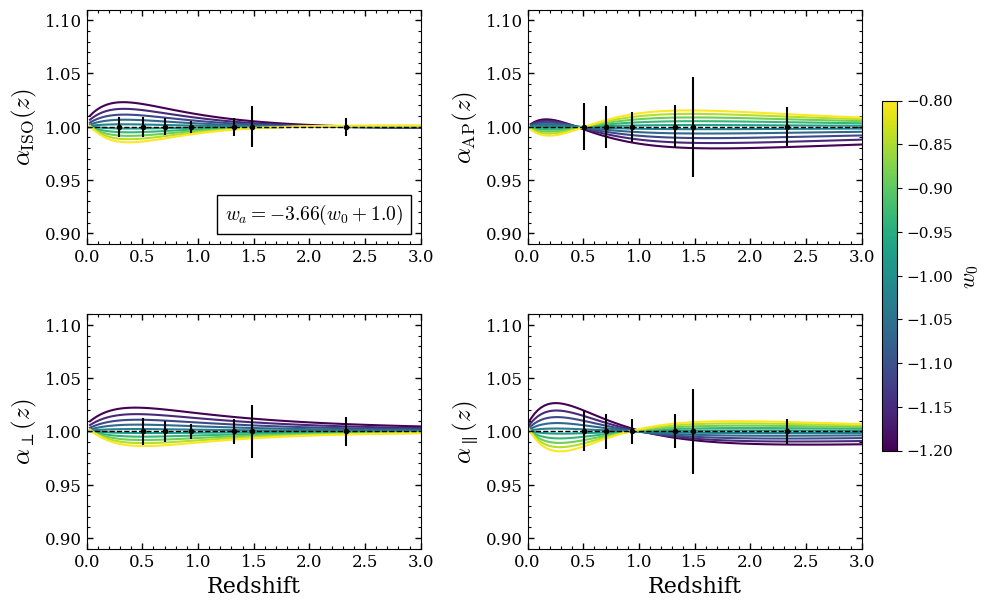

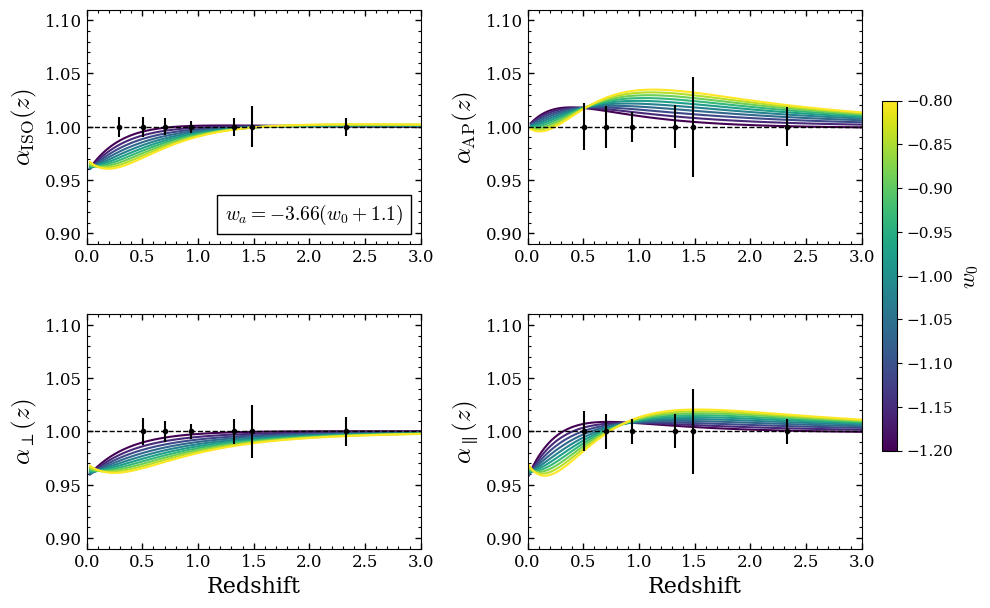

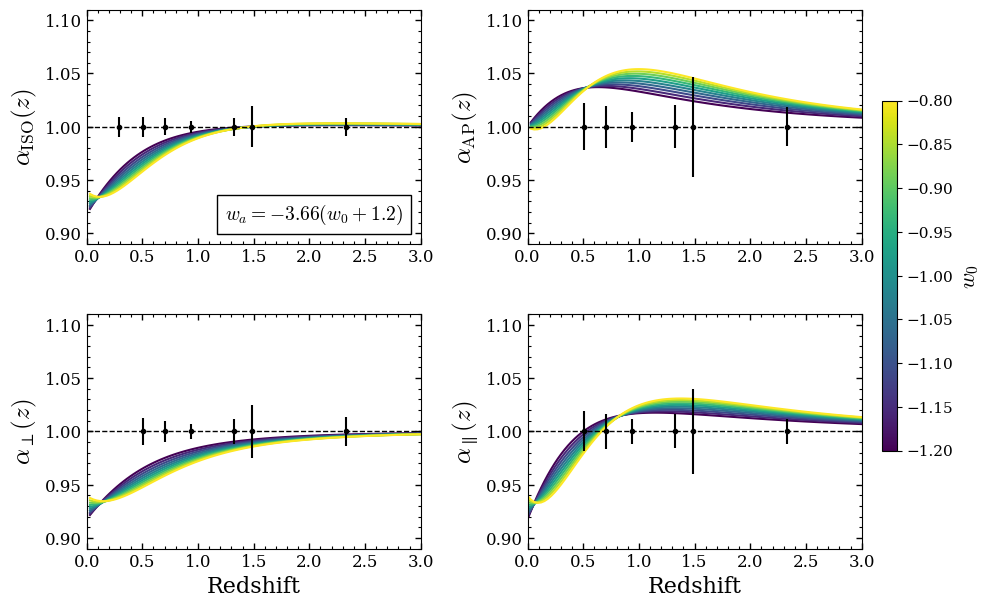

In [43]:
z = np.linspace(0.0, 3.0, 100)
DESI_errors = get_DESI_errors()
path = rf'..\..\figures\alpha_ratio\4plots\symmetric\Om_hrdrag_free'

for name, (slope, offset) in lines.items():
    plot_alpha_ratios(z, slope, offset, lines_param_sym[name], ylim={'all': (0.89, 1.11)}, name=name, 
                    DESI_errors=DESI_errors, symmetric=True)#, path_save=path, show_plots=False)
#     plot_alpha_ratios(z, slope, offset, lines_param_sym[name], ylim={'all': (0.89, 1.11)}, xlabel=False, name=name, 
#                       DESI_errors=DESI_errors, symmetric=True)#, path_save=path, show_plots=False)

In [ ]:
z = np.linspace(0.0, 3.0, 100)
DESI_errors = get_DESI_errors()
path = rf'..\..\figures\alpha_ratio\4plots\symmetric\Om_hrdrag_fixed'

# for name, (slope, offset) in lines.items():
#     plot_alpha_ratios(z, slope, offset, lines_param_sym_fixed[name], ylim={'all': (0.89, 1.11)}, name=name, 
#                     DESI_errors=DESI_errors, symmetric=True)#, path_save=path, show_plots=False)
#     plot_alpha_ratios(z, slope, offset, lines_param_sym_fixed[name], ylim={'all': (0.89, 1.11)}, xlabel=False, name=name, 
#                       DESI_errors=DESI_errors, symmetric=True)#, path_save=path, show_plots=False)

C:\Users\adrie\AppData\Local\Temp\ipykernel_44332\1331346918.py:30: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid


### 2 panels

C:\Users\adrie\AppData\Local\Temp\ipykernel_46704\1331346918.py:30: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid


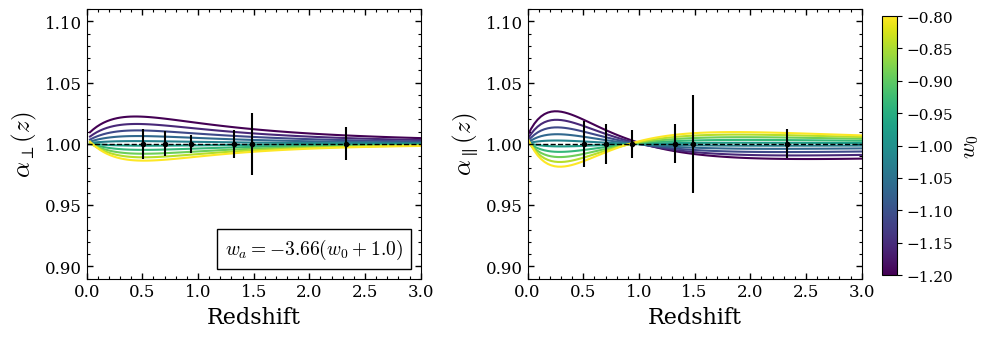

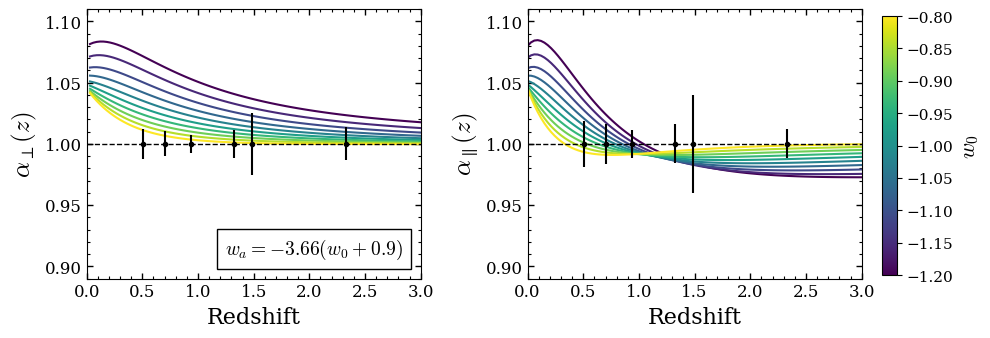

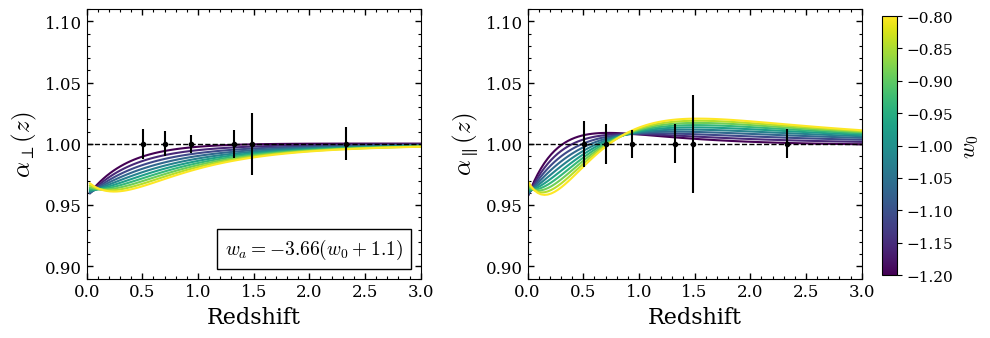

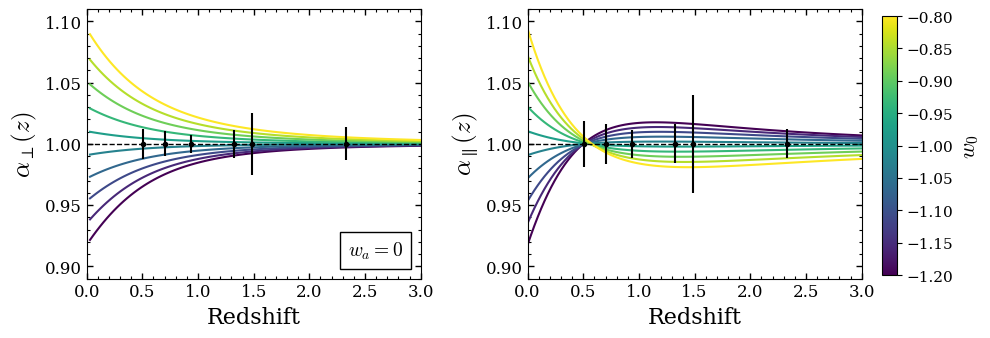

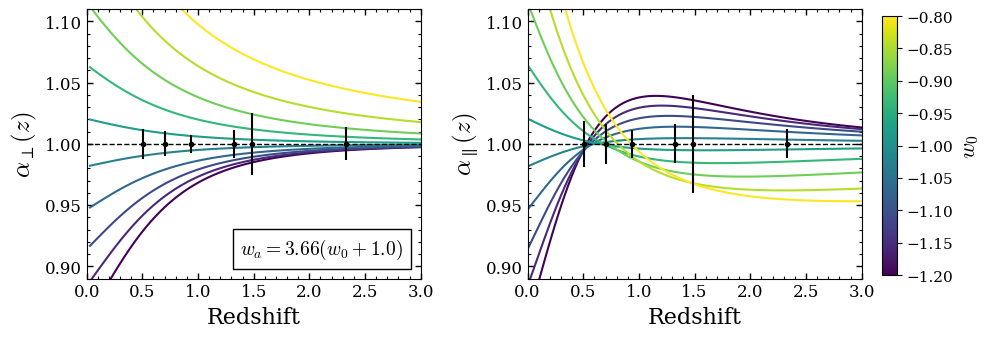

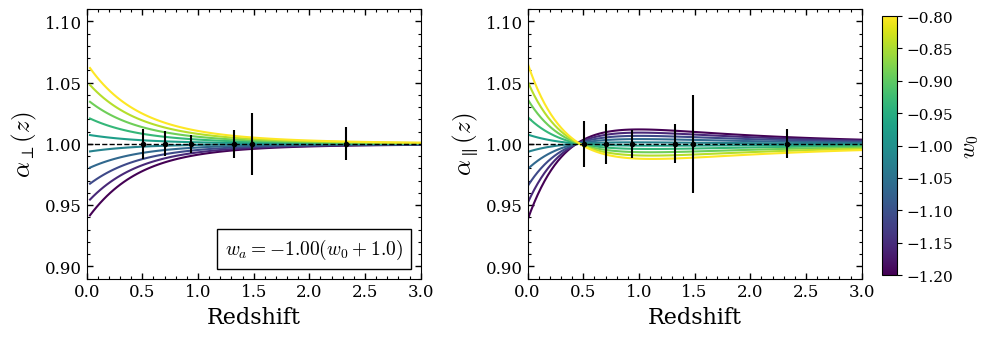

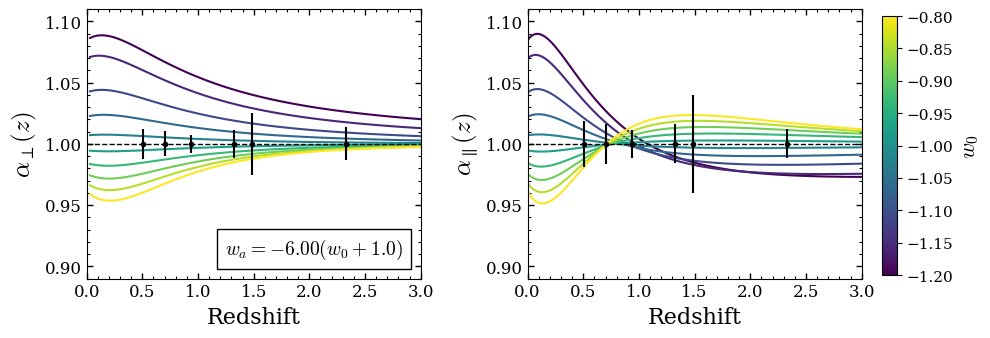

In [26]:
z = np.linspace(0.0, 3.0, 100)
DESI_errors = get_DESI_errors()
path = rf'..\..\figures\alpha_ratio\2plots\symmetric\Om_hrdrag_free'

for name, (slope, offset) in lines.items():
    plot_alpha_ratios_2panels(z, slope, offset, lines_param_sym[name], ylim={'all': (0.89, 1.11)}, name=name, 
                                DESI_errors=DESI_errors, symmetric=True, AP_ISO=False)#, path_save=path, show_plots=False)
#     plot_alpha_ratios_2panels(z, slope, offset, lines_param_sym[name], ylim={'all': (0.89, 1.11)}, xlabel=False, name=name, 
#                                 DESI_errors=DESI_errors, symmetric=True)#, path_save=path, show_plots=False)

In [ ]:
z = np.linspace(0.0, 3.0, 100)
DESI_errors = get_DESI_errors()
path = rf'..\..\figures\alpha_ratio\2plots\symmetric\Om_hrdrag_fixed'

# for name, (slope, offset) in lines.items():
#     plot_alpha_ratios_2panels(z, slope, offset, lines_param_sym_fixed[name], ylim={'all': (0.89, 1.11)}, name=name, 
#                                 DESI_errors=DESI_errors, symmetric=True)#, path_save=path, show_plots=False)
#     plot_alpha_ratios_2panels(z, slope, offset, lines_param_sym_fixed[name], ylim={'all': (0.89, 1.11)}, xlabel=False, name=name, 
#                                 DESI_errors=DESI_errors, symmetric=True)#, path_save=path, show_plots=False)

C:\Users\adrie\AppData\Local\Temp\ipykernel_45612\1331346918.py:30: RuntimeWarning: invalid value encountered in divide
  return DMover_rd_real / DMover_rd_fid, DHover_rd_real / DHover_rd_fid, DVover_rd_real / DVover_rd_fid
